In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns

from network_original_lpn import LPN
from network_ne_by_norm import NE_LPN_By_Norm
from network_ne_by_design import NE_LPN_By_Design
from utils import prox, cvx, prior, gt_cvx, prox_gaussian, gt_cvx_split_normal, split_normal_log_prior, prox_split_normal

sns.set()

MODEL_DIR = "experiments/models/"
PLOT_DIR = "experiments/plots/"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

np.random.seed(1)
torch.manual_seed(1)

In [2]:
class NormalSampler:
    def __init__(self, mean=0.0, std=1.0):
        self.mean = mean
        self.std = std

    def __call__(self, n):
        return torch.randn(n) * self.std + self.mean

def add_noise(x, sigma=0.1):
    return x + torch.randn_like(x) * sigma

def exp_func(x, gamma):
    return -torch.exp(-((x / gamma) ** 2)) + 1

In [3]:
class SplitNormalSampler:
    def __init__(self, mean: float = 0.0, std_left: float = 1.0, std_right: float = 2.0):
        self.mean = mean
        self.std_left = std_left
        self.std_right = std_right
        self.p_left = std_left / (std_left + std_right)

    def __call__(self, n: int):
        u = torch.rand(n)
        z = torch.randn(n).abs()
        samples = torch.where(
            u < self.p_left,
            self.mean - z * self.std_left,
            self.mean + z * self.std_right
        )
        return samples

In [4]:
def single_iteration(model, bsize, sigma_noise, optimizer, sampler, loss_type, gamma_loss=None):
    target = sampler(bsize).unsqueeze(1).to(device)
    input_ = add_noise(target, sigma_noise).to(device)
    output = model(input_)

    if loss_type == 2:
        loss = torch.nn.functional.mse_loss(output, target)
    elif loss_type == 1:
        loss = torch.nn.functional.l1_loss(output, target)
    elif loss_type == 0:
        loss = exp_func(output - target, gamma_loss).mean()
    else:
        raise ValueError("Invalid loss_type")

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if hasattr(model, "wclip"):
        model.wclip()
    return loss.item()


In [5]:
def plot_all(model, title, mean=0.0, stdev_right=2.0, stdev_left=1.0):
    xi = np.linspace(-8, 8, 1000)
    y = prox(xi, model)
    c = cvx(xi, model)
    p = prior(xi, model)

    fig, axs = plt.subplots(1, 3, figsize=(8, 3))
    axs[0].plot(xi, y, label="LPN")
    axs[0].plot(xi, prox_split_normal(xi), '--', label="split normal prox")
    axs[0].set_title("Learned prox")
    axs[0].grid(True)
    axs[0].legend()

    axs[1].plot(xi, c - c.min(), label="Cvx func")
    axs[1].plot(xi, gt_cvx_split_normal(xi), '--', label="ref.")
    axs[1].set_title("Cvx func")
    axs[1].grid(True)
    axs[1].legend()

    axs[2].plot(xi, p - p.min(), label="LPN")
    axs[2].plot(xi, split_normal_log_prior(xi, mean, stdev_left, stdev_right), '--', label="split normal log-prior")
    axs[2].set_title("Original func")
    axs[2].grid(True)
    axs[2].legend()

    fig.suptitle(title)
    fig.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, f"{title}_plot.png"))
    plt.show()

In [6]:
def plot_comparison(models, mean=0.0, stdev_right=2.0, stdev_left=1.0):
    xi = np.linspace(-8, 8, 1000)
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))

    for name, model in models.items():
        y = prox(xi, model)
        c = cvx(xi, model)
        p = prior(xi, model)

        axs[0].plot(xi, y, label=name)
        axs[1].plot(xi, c - c.min(), label=name)
        axs[2].plot(xi, p - p.min(), label=name)

    axs[0].plot(xi, prox_split_normal(xi), '--', label="split normal prox")
    axs[0].set_title("Learned prox")
    axs[1].plot(xi, gt_cvx_split_normal(xi), '--', label="ref.")
    axs[1].set_title("Cvx func")
    axs[2].plot(xi, split_normal_log_prior(xi, mean, stdev_left, stdev_right), '--', label="split normal log-prior")
    axs[2].set_title("Original func")

    for ax in axs:
        ax.grid(True)
        ax.legend()

    plt.suptitle("Model Comparison")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, "model_comparison.png"))
    plt.show()
    

In [7]:
def train_model(model, model_name, loss_type, gamma_loss, sampler, sigma_noise, 
                lr_schedule, iterations_per_phase):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr_schedule[0])
    bsize = 2000
    loss_log = []

    print(f"Training {model_name}...")
    for phase, lr in enumerate(lr_schedule):
        for g in optimizer.param_groups:
            g['lr'] = lr
        for i in range(iterations_per_phase):
            loss = single_iteration(model, bsize, sigma_noise, optimizer, sampler, loss_type, gamma_loss)
            if i % 100 == 0:
                print(f"{model_name} | Phase {phase+1}/{len(lr_schedule)} | Iter {i}: Loss = {loss:.6f}")
                loss_log.append(loss)

    # Save and plot
    model_path = os.path.join(MODEL_DIR, f"{model_name}.pth")
    torch.save(model.state_dict(), model_path)
    plot_all(model, title=model_name)
    return model
    

In [ ]:
mean, std_left, std_right = 0.0, 1.0, 2.0
sampler = SplitNormalSampler(mean=mean, std_left=std_left, std_right=std_right) 
sigma_noise = 1.0
loss_type = 0
gamma_loss = 0.1
lr_schedule = [1e-5, 1e-4]
iterations_per_phase = 10000

In [9]:
dim = 1
hidden = 50
layers = 4
beta = 10

In [14]:
def get_models():
    return {
        "NE_By_Design": NE_LPN_By_Design(in_dim=dim, hidden=hidden, layers=layers, beta=beta),
        "NE_By_Norm": NE_LPN_By_Norm(in_dim=dim, hidden=hidden, layers=layers, beta=beta),
        "Original_LPN": LPN(in_dim=dim, hidden=hidden, layers=layers, beta=beta),
    }

In [15]:
trained_models = {}
for name, model in get_models().items():
    trained_models[name] = train_model(model, name, loss_type, gamma_loss, 
                                       sampler=sampler, sigma_noise=sigma_noise, 
                                       lr_schedule=lr_schedule, iterations_per_phase=iterations_per_phase)

Training NE_By_Design...
NE_By_Design | Phase 1/2 | Iter 0: Loss = 0.929397
NE_By_Design | Phase 1/2 | Iter 100: Loss = 0.929246
NE_By_Design | Phase 1/2 | Iter 200: Loss = 0.926053
NE_By_Design | Phase 1/2 | Iter 300: Loss = 0.919719
NE_By_Design | Phase 1/2 | Iter 400: Loss = 0.936759
NE_By_Design | Phase 1/2 | Iter 500: Loss = 0.928076
NE_By_Design | Phase 1/2 | Iter 600: Loss = 0.938489
NE_By_Design | Phase 1/2 | Iter 700: Loss = 0.940197
NE_By_Design | Phase 1/2 | Iter 800: Loss = 0.928233
NE_By_Design | Phase 1/2 | Iter 900: Loss = 0.931269
NE_By_Design | Phase 1/2 | Iter 1000: Loss = 0.927531
NE_By_Design | Phase 1/2 | Iter 1100: Loss = 0.930840
NE_By_Design | Phase 1/2 | Iter 1200: Loss = 0.931392
NE_By_Design | Phase 1/2 | Iter 1300: Loss = 0.924810
NE_By_Design | Phase 1/2 | Iter 1400: Loss = 0.926953
NE_By_Design | Phase 1/2 | Iter 1500: Loss = 0.931702
NE_By_Design | Phase 1/2 | Iter 1600: Loss = 0.926105
NE_By_Design | Phase 1/2 | Iter 1700: Loss = 0.922596
NE_By_Design | 

KeyboardInterrupt: 

mse 21.384931564331055
mse 16.58786392211914
mse 13.155577659606934
mse 10.613211631774902
mse 8.038553237915039
mse 6.487998962402344
mse 5.770847320556641
mse 4.964867115020752
mse 4.696416854858398
mse 4.5925140380859375
mse 4.556143760681152
mse 4.540395259857178
mse 4.531282424926758
mse 4.524505615234375
mse 4.51780891418457
mse 4.5054779052734375
mse 4.415374279022217
mse 4.324731826782227
mse 4.256985664367676
mse 4.195703029632568
mse 4.068746566772461
mse 3.914356231689453
mse 3.798717975616455
mse 3.739396095275879
mse 3.7065093517303467
mse 3.686519145965576
mse 3.6734158992767334
mse 3.6642589569091797
mse 3.657478094100952
mse 3.6521706581115723
mse 3.6477839946746826
mse 3.6439590454101562
mse 3.640449285507202
mse 3.637073278427124
mse 3.633690595626831
mse 3.6301796436309814
mse 3.6264212131500244
mse 3.622270345687866
mse 3.6175079345703125
mse 3.611729860305786
mse 3.6040666103363037
mse 3.5922341346740723
mse 3.5682177543640137
mse 3.5175106525421143
mse 3.462819337

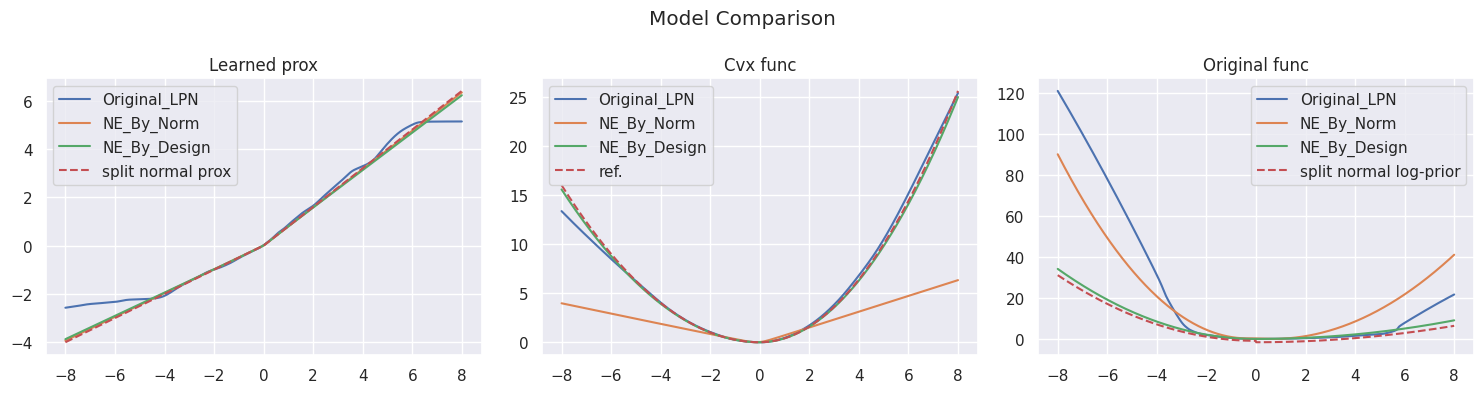

All models trained and plotted.


In [ ]:
plot_comparison(trained_models)
print("All models trained and plotted.")

mse 21.382314682006836
mse 16.868070602416992
mse 13.325688362121582
mse 10.494046211242676
mse 8.241576194763184
mse 6.455003261566162
mse 5.041870594024658
mse 3.9272446632385254
mse 3.050499677658081
mse 2.362684726715088
mse 1.8244030475616455
mse 1.4040837287902832
mse 1.0765564441680908
mse 0.8218598961830139
mse 0.624241054058075
mse 0.4713171422481537
mse 0.35337865352630615
mse 0.2628170847892761
mse 0.19366352260112762
mse 0.14122284948825836
mse 0.10178987681865692
mse 0.07243205606937408
mse 0.050824832171201706
mse 0.03512698411941528
mse 0.02388547919690609
mse 0.01596119813621044
mse 0.010470022447407246
mse 0.006734197493642569
mse 0.004242061171680689
mse 0.0026139821857213974
mse 0.001573725021444261
mse 0.000924488587770611
mse 0.0005292188143357635
mse 0.00029479869408532977
mse 0.00015956233255565166
mse 8.378773782169446e-05
mse 4.261443609721027e-05
mse 2.0955158106517047e-05
mse 9.94535548670683e-06
mse 4.546584477793658e-06
mse 1.998164407268632e-06
mse 8.42330

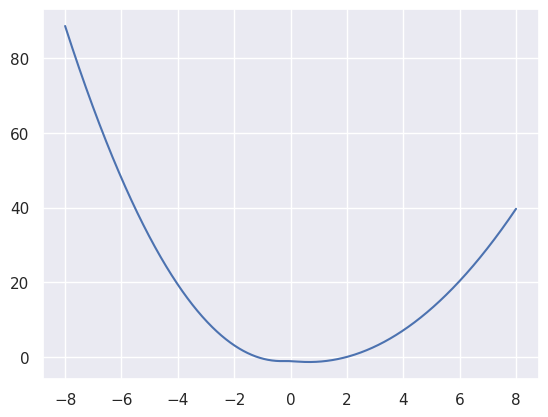

In [ ]:
xi = np.linspace(-8, 8, 1000)
pi = prior(xi, trained_models["NE_By_Norm"])
print("prior shape: ", pi.shape)
plt.plot(xi, pi, label="Learned Prior")